In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, fbeta_score
import sys
sys.path.append(r"D:\baitaplon\hr-churn-predictor\hr-churn-predictor\backend")
from custom_transformers.lr_transformers import LR_MissingValueHandler, LR_OrdinalMapper, LR_FrequencyEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Tải dữ liệu từ Google Drive
file_id = '1e8ImAsI7nDfDyyDCRo6cy2Bde1WEa_mY'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df_raw = pd.read_csv(url)

df_raw.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [3]:
# Loại bỏ enrollee_id vì không có giá trị dự đoán
df = df_raw.drop(columns=['enrollee_id'])

# Tách feature matrix X và vector nhãn y
X = df.drop(columns=['target'])
y = df['target'].astype(int)

# Train/Test Split 80/20 với stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} mẫu')
print(f'Test set: {X_test.shape[0]} mẫu')

Train set: 15326 mẫu
Test set: 3832 mẫu


In [4]:
# class MissingValueHandler(BaseEstimator, TransformerMixin):
#     UNKNOWN_COLS = ['gender', 'company_size', 'company_type']
#     NO_INFO_COLS = ['major_discipline']
#     MODE_COLS = ['relevent_experience', 'enrolled_university',
#                  'education_level', 'experience', 'last_new_job']
#     MEDIAN_COLS = ['city_development_index', 'training_hours']

#     def fit(self, X, y=None):
#         self.modes_ = {col: X[col].mode()[0] for col in self.MODE_COLS if col in X.columns}
#         self.medians_ = {col: X[col].median() for col in self.MEDIAN_COLS if col in X.columns}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col in self.UNKNOWN_COLS:
#             if col in X.columns: X[col] = X[col].fillna('Unknown')
#         for col in self.NO_INFO_COLS:
#             if col in X.columns: X[col] = X[col].fillna('No Info')
#         for col, val in self.modes_.items():
#             if col in X.columns: X[col] = X[col].fillna(val)
#         for col, val in self.medians_.items():
#             if col in X.columns: X[col] = X[col].fillna(val)
#         return X

# class OrdinalMapperLinear(BaseEstimator, TransformerMixin):
#     # Với mô hình tuyến tính, company_size sẽ được One-Hot Encoding thay vì Ordinal
#     MAPPINGS = {
#         'education_level': {'Primary School':0,'High School':1,'Graduate':2,'Masters':3,'Phd':4},
#         'experience' : {'<1':0, **{str(i):i for i in range(1,21)}, '>20':21},
#         'last_new_job' : {'never':0,'1':1,'2':2,'3':3,'4':4,'>4':5},
#     }
#     def fit(self, X, y=None): return self
#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.MAPPINGS.items():
#             if col in X.columns: X[col] = X[col].map(mapping)
#         return X

# class FrequencyEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, col='city'): self.col = col
#     def fit(self, X, y=None):
#         
#         self.freq_map_ = X[self.col].value_counts(normalize=True).to_dict()
#         return self
#     def transform(self, X, y=None):
#         X = X.copy()
#         X[self.col] = X[self.col].map(self.freq_map_).fillna(0.0)
#         return X

In [5]:
# Các tập hợp cột
OHE_COLS_LINEAR = ['gender', 'relevent_experience', 'enrolled_university',
                   'major_discipline', 'company_type', 'company_size']
FREQ_COL = 'city'

# Column Transformer cho Logistic Regression
# Bao gồm StandardScale cho CDI, City và Log1p+Scale cho training_hours
col_transformer_linear = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), OHE_COLS_LINEAR),
        ('scaler_std', StandardScaler(), ['city_development_index', FREQ_COL]),
        ('log1p_std', Pipeline([
            ('log', FunctionTransformer(np.log1p, validate=True)),
            ('scale', StandardScaler()),
        ]), ['training_hours']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)

# Kết hợp thành Full Pipeline với Logistic Regression
full_pipeline_lr = Pipeline(steps=[
    ('missing_handler', LR_MissingValueHandler()),
    ('ordinal_mapper', LR_OrdinalMapper()),
    ('freq_encoder', LR_FrequencyEncoder(col=FREQ_COL)),
    ('col_transformer', col_transformer_linear),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

In [6]:
# Fit toàn bộ pipeline trên tập Train
print("Đang huấn luyện mô hình Baseline Logistic Regression...")
full_pipeline_lr.fit(X_train, y_train)
print("Huấn luyện thành công!")

Đang huấn luyện mô hình Baseline Logistic Regression...
Huấn luyện thành công!


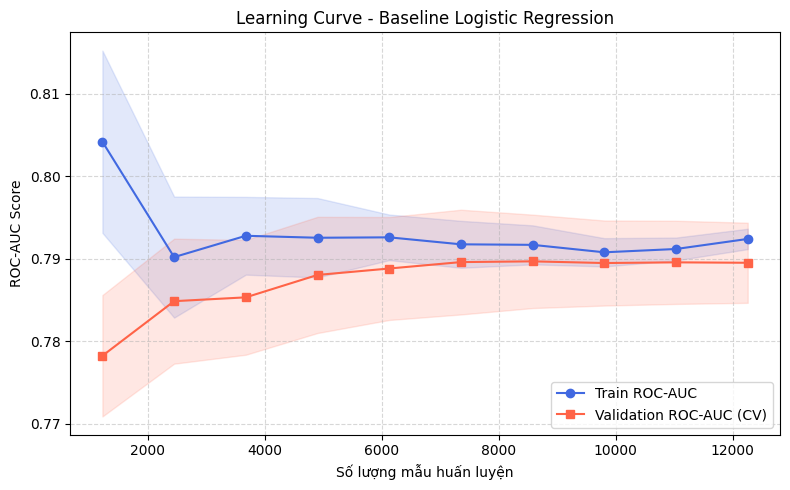

In [7]:
# ── LEARNING CURVE ──────────────────────────────────────────────────────────
# Dùng cross-validation trên TẬP TRAIN để tránh data leakage
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    full_pipeline_lr,
    X_train, y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation ROC-AUC (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='tomato')
plt.title('Learning Curve - Baseline Logistic Regression')
plt.xlabel('Số lượng mẫu huấn luyện')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ROC-AUC: 0.8044
PR-AUC: 0.5481
F2-Score: 0.7085

Báo cáo phân loại (Classification Report):
                    precision    recall  f1-score   support

0 - Không tìm việc       0.91      0.75      0.83      2877
 1 - Đang tìm việc       0.51      0.78      0.62       955

          accuracy                           0.76      3832
         macro avg       0.71      0.77      0.72      3832
      weighted avg       0.81      0.76      0.78      3832



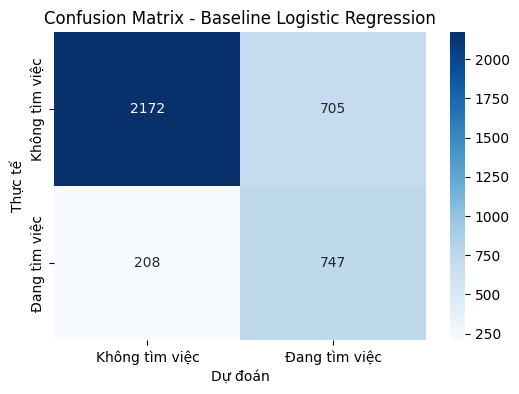

In [8]:
# Dự đoán trên tập Test
y_pred = full_pipeline_lr.predict(X_test)
y_pred_proba = full_pipeline_lr.predict_proba(X_test)[:, 1]

# Tính toán các metric
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
f2_score_val = fbeta_score(y_test, y_pred, beta=2)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"F2-Score: {f2_score_val:.4f}\n")
print("Báo cáo phân loại (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['0 - Không tìm việc', '1 - Đang tìm việc']))

# Trực quan hóa Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Không tìm việc', 'Đang tìm việc'], yticklabels=['Không tìm việc', 'Đang tìm việc'])
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

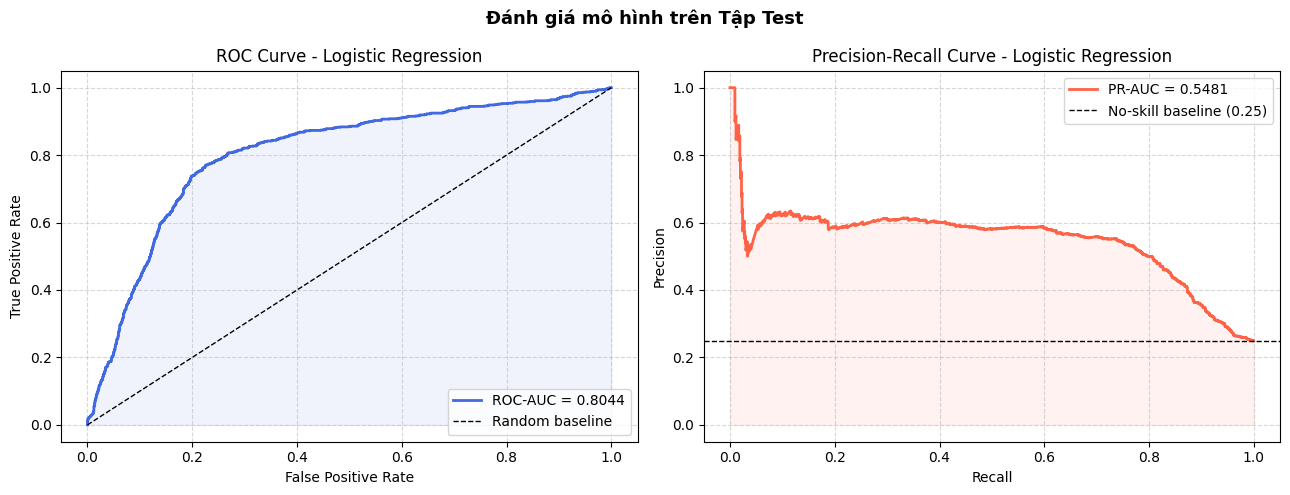

In [9]:
# ── ROC AUC CURVE & PR AUC CURVE ────────────────────────────────────────────
from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                              roc_curve, precision_recall_curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='royalblue', lw=2,
             label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='royalblue')
axes[0].set_title('ROC Curve - Logistic Regression')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- PR Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
no_skill = y_test.mean()   # tỷ lệ positive class
axes[1].plot(recall_vals, precision_vals, color='tomato', lw=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=no_skill, color='k', linestyle='--', lw=1,
                label=f'No-skill baseline ({no_skill:.2f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.08, color='tomato')
axes[1].set_title('Precision-Recall Curve - Logistic Regression')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Đánh giá mô hình trên Tập Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

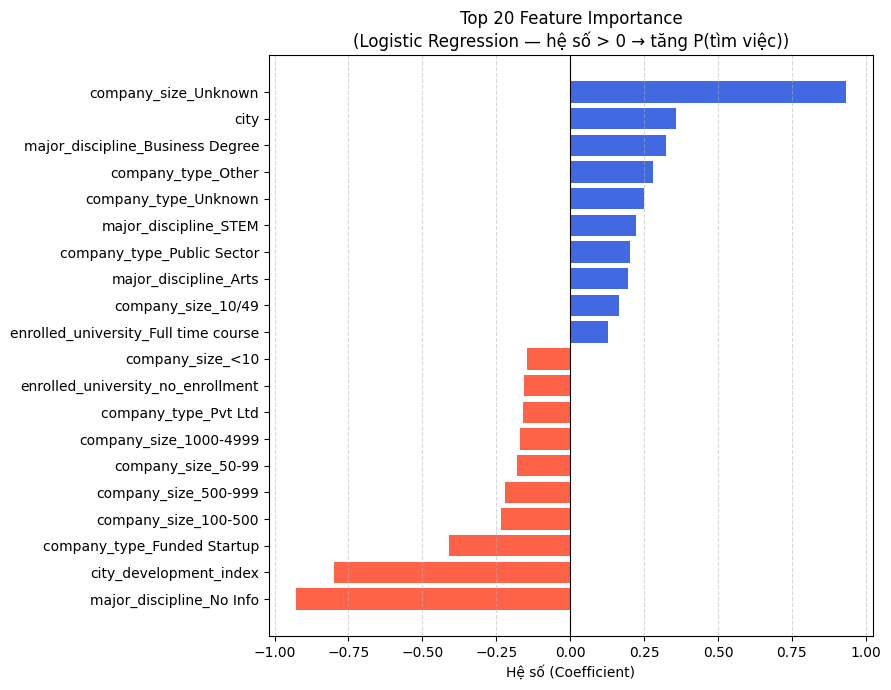


Top 10 feature ảnh hưởng nhiều nhất:
                         feature  coefficient  abs_coef
            company_size_Unknown     0.931715  0.931715
        major_discipline_No Info    -0.926472  0.926472
          city_development_index    -0.797593  0.797593
     company_type_Funded Startup    -0.410127  0.410127
                            city     0.359099  0.359099
major_discipline_Business Degree     0.325784  0.325784
              company_type_Other     0.278779  0.278779
            company_type_Unknown     0.250134  0.250134
            company_size_100-500    -0.234344  0.234344
           major_discipline_STEM     0.222593  0.222593


In [10]:
# ── FEATURE IMPORTANCE (Logistic Regression Coefficients) ───────────────────
fitted_ct = full_pipeline_lr.named_steps['col_transformer']

# --- Lấy tên từng nhóm transformer thủ công (tránh lỗi FunctionTransformer) ---
# 1. OHE features
ohe_names = fitted_ct.named_transformers_['ohe'].get_feature_names_out(OHE_COLS_LINEAR)

# 2. StandardScaler features (giữ nguyên tên cột đầu vào)
scaler_names = np.array(['city_development_index', FREQ_COL])

# 3. Log1p + Scale: chỉ có 1 cột
log_names = np.array(['training_hours'])

# 4. Remainder (passthrough): education_level, experience, last_new_job
#    Xác định bằng cách loại trừ các cột đã dùng
used_cols = list(OHE_COLS_LINEAR) + ['city_development_index', FREQ_COL, 'training_hours']
remainder_names = np.array([c for c in X_train.columns if c not in used_cols])

# Ghép tất cả theo đúng thứ tự ColumnTransformer
feature_names = np.concatenate([ohe_names, scaler_names, log_names, remainder_names])
coefficients  = full_pipeline_lr.named_steps['model'].coef_[0]

feat_imp_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
    .assign(abs_coef=lambda df: df['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)

# Vẽ Top 20
top_n  = 20
plot_df = feat_imp_df.head(top_n).sort_values('coefficient')
colors  = ['tomato' if c < 0 else 'royalblue' for c in plot_df['coefficient']]

plt.figure(figsize=(9, 7))
plt.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} Feature Importance\n(Logistic Regression — hệ số > 0 → tăng P(tìm việc))',
          fontsize=12)
plt.xlabel('Hệ số (Coefficient)')
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

print("\nTop 10 feature ảnh hưởng nhiều nhất:")
print(feat_imp_df[['feature', 'coefficient', 'abs_coef']].head(10).to_string(index=False))

In [11]:
# Lưu mô hình Logistic Regression
import joblib
lr_model_filename = 'logistic_regression_baseline.pkl'
joblib.dump(full_pipeline_lr, lr_model_filename)

print(f"Đã lưu mô hình Logistic Regression tại: {lr_model_filename}")

Đã lưu mô hình Logistic Regression tại: logistic_regression_baseline.pkl


LightGBM
